In [1]:
file_path = '/home/jthybo/connect_wsl/resources/montepython_public/chains/SIDR_interacting_and_std_T_3_2mio/'
file_name = '2026-03-16_2000000__2.txt'
full_path = file_path + file_name
header_path = '/home/jthybo/connect_wsl/resources/montepython_public/chains/SIDR_interacting_and_std_T_3_2mio/2026-03-16_2000000_.paramnames'

In [2]:
import pandas as pd
df = pd.read_csv(full_path, sep=r"\s+", header=None, engine="python")

with open(header_path, 'r') as f:
    header = [line.split()[0] for line in f.readlines()]

column_names = ["step", "-loglike"] + header
df.columns = column_names
print("Data columns:", df.shape[1])
print("Header names:", len(column_names))

Data columns: 29
Header names: 29


In [4]:
columns_to_plot = column_names[1::10][:2]
print("Columns to plot:", columns_to_plot)

keep_every_x_point = 1

x = pd.to_numeric(df[columns_to_plot[1]], errors='coerce').iloc[::keep_every_x_point]
y = pd.to_numeric(df[columns_to_plot[0]], errors='coerce').iloc[::keep_every_x_point]

mask = ~x.isna() & ~y.isna()
x = x[mask]
y = y[mask]

x_test = df[columns_to_plot[1]]
y_test = df[columns_to_plot[0]]

print('min value of deg_ncdm_interacting:', x.min())
print('max_value of deg_ncdm_interacting:', x.max())
print('min value of -loglike:', y.min())
print('max value of -loglike:', y.max())



Columns to plot: ['-loglike', 'deg_ncdm_interacting']
min value of deg_ncdm_interacting: 7.226443e-05
max_value of deg_ncdm_interacting: 3.722602
min value of -loglike: 17303.8
max value of -loglike: 25667.8


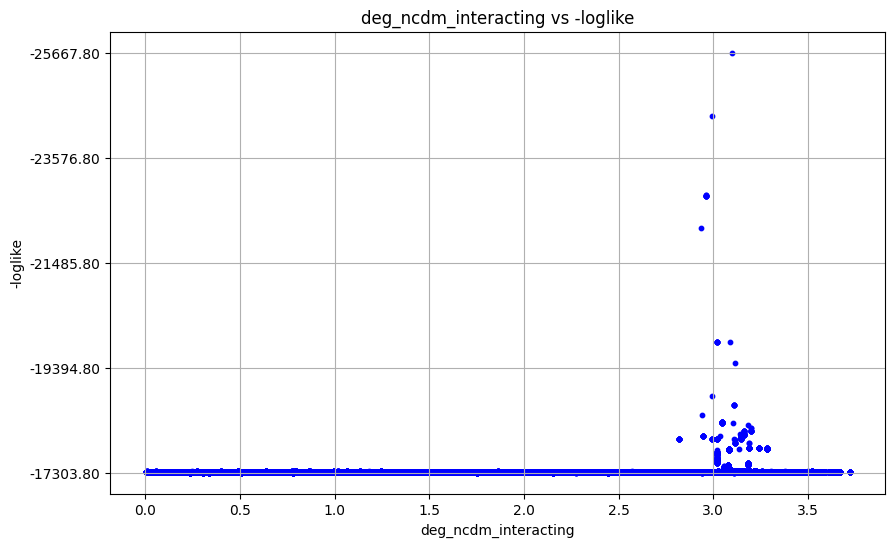

701961 701961


In [5]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 6))
plt.scatter(x, y, s=10, marker='o', linestyle='-', color='blue')
plt.title(f'{columns_to_plot[1]} vs {columns_to_plot[0]}')
plt.xlabel(columns_to_plot[1])
plt.ylabel(columns_to_plot[0])
yticks= np.linspace(y.min(), y.max(), 5)
plt.yticks(yticks, labels=[f"-{tick:.2f}" for tick in yticks])

plt.grid()
plt.show()

print(len(x), len(y))

In [6]:
import pandas as pd
import glob
import os

# Folder containing all your txt files
folder_path = "/home/jthybo/connect_wsl/resources/montepython_public/chains/SIDR_interacting_and_std_T_3_2mio/"

# Pattern to match files, e.g., all txt files starting with "2026-03"
file_pattern = os.path.join(folder_path, "2026-03*.txt")

# Get a list of all matching files
txt_files = glob.glob(file_pattern)
print("Found files:", txt_files)

combined_dataset = np.vstack([np.loadtxt(file) for file in txt_files])

x = combined_dataset[:, 11]  # deg_ncdm_interacting
y = combined_dataset[:, 1]  # -loglike


sort_idx = np.argsort(x)
x_sorted = x[sort_idx]
y_sorted = y[sort_idx]

bins_width = 0.06
x_min, x_max = x.min(), x.max()
y_min, y_max = y.min(), y.max()
print(f"x range: {x_min:.2f} to {x_max:.2f}")
print(f"y range: {y_min:.2f} to {y_max:.2f}")




Found files: ['/home/jthybo/connect_wsl/resources/montepython_public/chains/SIDR_interacting_and_std_T_3_2mio/2026-03-16_2000000__1.txt', '/home/jthybo/connect_wsl/resources/montepython_public/chains/SIDR_interacting_and_std_T_3_2mio/2026-03-16_2000000__0.txt', '/home/jthybo/connect_wsl/resources/montepython_public/chains/SIDR_interacting_and_std_T_3_2mio/2026-03-16_2000000__3.txt', '/home/jthybo/connect_wsl/resources/montepython_public/chains/SIDR_interacting_and_std_T_3_2mio/2026-03-16_2000000__4.txt', '/home/jthybo/connect_wsl/resources/montepython_public/chains/SIDR_interacting_and_std_T_3_2mio/2026-03-16_2000000__5.txt', '/home/jthybo/connect_wsl/resources/montepython_public/chains/SIDR_interacting_and_std_T_3_2mio/2026-03-16_2000000__2.txt']
x range: 0.00 to 3.78
y range: 17241.40 to 28211.90


17363.1 26757.8
17242.1 25763.9
17411.1 28211.9
17330.3 26246.3
17248.1 25319.5
17305.3 25667.8
Global min value of -loglike: 17241.0
Global max value of -loglike: 17280.0


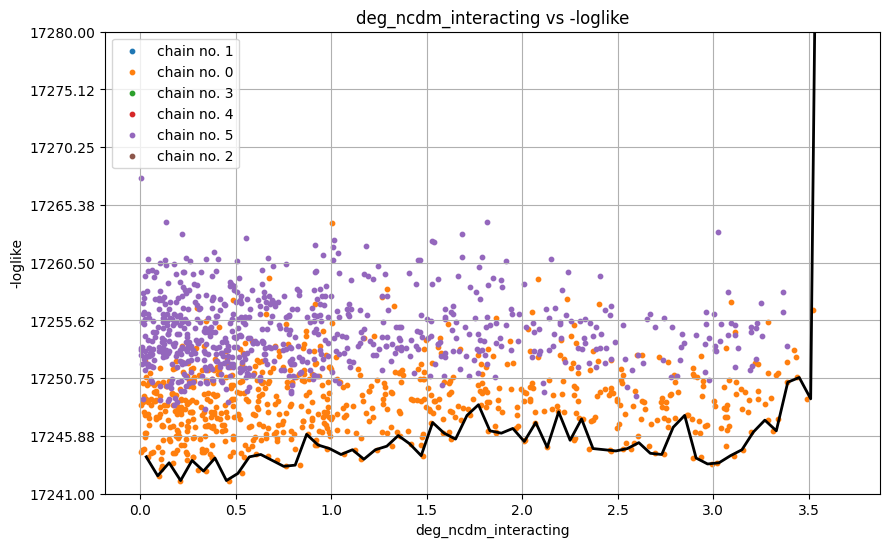

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import glob
import os

folder_path = "/home/jthybo/connect_wsl/resources/montepython_public/chains/SIDR_interacting_and_std_T_3_2mio/"
file_pattern = os.path.join(folder_path, "2026-03*.txt")
txt_files = glob.glob(file_pattern)

plt.figure(figsize=(10, 6))

# Global plotting limits
y_max_glob = 17280.0
y_min_glob = 17241.0

# Downsampling step
step = 1000

# Store all data (downsampled)
all_data = []

# ----------- LOAD + DOWNSAMPLE + PLOT ----------- #
for file in txt_files:
    filename = os.path.basename(file)
    chain_number = int(filename.split("__")[-1].replace(".txt", ""))
    label = f"chain no. {chain_number}"

    # Load only needed columns: column 1 (-loglike) and 11 (deg_ncdm_interacting)
    data = np.loadtxt(file, usecols=(1, 11))  # -loglike, deg_ncdm_interacting

    # Downsample immediately
    data = data[::step]

    # Store for combined dataset
    all_data.append(data)

    x_chain = data[:, 1]  # deg_ncdm_interacting
    
    y_chain = data[:, 0]  # -loglike
    print(y_chain.min(), y_chain.max())
    plt.scatter(x_chain, y_chain, s=10, marker='o', label=label)

# ----------- COMBINE DATA ----------- #
combined_dataset = np.vstack(all_data)

x = combined_dataset[:, 1]  # deg_ncdm_interacting
y = combined_dataset[:, 0]  # -loglike

# ----------- SORT FOR BINNING ----------- #
sort_idx = np.argsort(x)
x_sorted = x[sort_idx]
y_sorted = y[sort_idx]

# ----------- BINNING FOR TREND LINE ----------- #
bins_width = 0.06
bins = np.arange(x.min(), x.max() + bins_width, bins_width)

trend_x = []
trend_y = []

for i in range(len(bins) - 1):
    mask = (x_sorted >= bins[i]) & (x_sorted < bins[i + 1])
    y_in_bin = y_sorted[mask]

    if len(y_in_bin) > 0:
        trend_y.append(y_in_bin.min())
        trend_x.append((bins[i] + bins[i + 1]) / 2)

trend_x = np.array(trend_x)
trend_y = np.array(trend_y)

# ----------- TREND LINE ----------- #
plt.plot(trend_x, trend_y, color='black', linestyle='-', linewidth=2)

# ----------- FINAL PLOT SETTINGS ----------- #
plt.title('deg_ncdm_interacting vs -loglike')
plt.xlabel('deg_ncdm_interacting')
plt.ylabel('-loglike')

print('Global min value of -loglike:', y_min_glob)
print('Global max value of -loglike:', y_max_glob)

plt.yticks(np.linspace(y_min_glob, y_max_glob, 9))
plt.ylim(y_min_glob, y_max_glob)

plt.legend(loc='upper left')
plt.grid()

plt.show()

In [9]:
#Now doing it for the 1mio chains that work

import pandas as pd
import glob
import os

# Folder containing all your txt files
folder_path = "/home/jthybo/connect_wsl/resources/montepython_public/chains/SIDR_interacting_and_std_T_3_1mio/"

# Pattern to match files, e.g., all txt files starting with "2026-03"
file_pattern = os.path.join(folder_path, "2026-03*.txt")

# Get a list of all matching files
txt_files = glob.glob(file_pattern)
print("Found files:", txt_files)

combined_dataset = np.vstack([np.loadtxt(file) for file in txt_files])

x = combined_dataset[:, 11]  # deg_ncdm_interacting
y = combined_dataset[:, 1]  # -loglike


sort_idx = np.argsort(x)
x_sorted = x[sort_idx]
y_sorted = y[sort_idx]

bins_width = 0.06
x_min, x_max = x.min(), x.max()
y_min, y_max = y.min(), y.max()
print(f"x range: {x_min:.2f} to {x_max:.2f}")
print(f"y range: {y_min:.2f} to {y_max:.2f}")




Found files: ['/home/jthybo/connect_wsl/resources/montepython_public/chains/SIDR_interacting_and_std_T_3_1mio/2026-03-03_1000000__5.txt', '/home/jthybo/connect_wsl/resources/montepython_public/chains/SIDR_interacting_and_std_T_3_1mio/2026-03-03_1000000__2.txt', '/home/jthybo/connect_wsl/resources/montepython_public/chains/SIDR_interacting_and_std_T_3_1mio/2026-03-03_1000000__3.txt', '/home/jthybo/connect_wsl/resources/montepython_public/chains/SIDR_interacting_and_std_T_3_1mio/2026-03-03_1000000__4.txt', '/home/jthybo/connect_wsl/resources/montepython_public/chains/SIDR_interacting_and_std_T_3_1mio/2026-03-03_1000000__0.txt', '/home/jthybo/connect_wsl/resources/montepython_public/chains/SIDR_interacting_and_std_T_3_1mio/2026-03-03_1000000__1.txt']
x range: 0.00 to 3.88
y range: 16890.30 to 29247.40


16891.2 22081.6
16890.9 28988.6
16891.1 27127.8
16891.5 24230.8
16890.8 29247.4
16891.3 23684.6
Global min value of -loglike: 16890.0
Global max value of -loglike: 16898.0


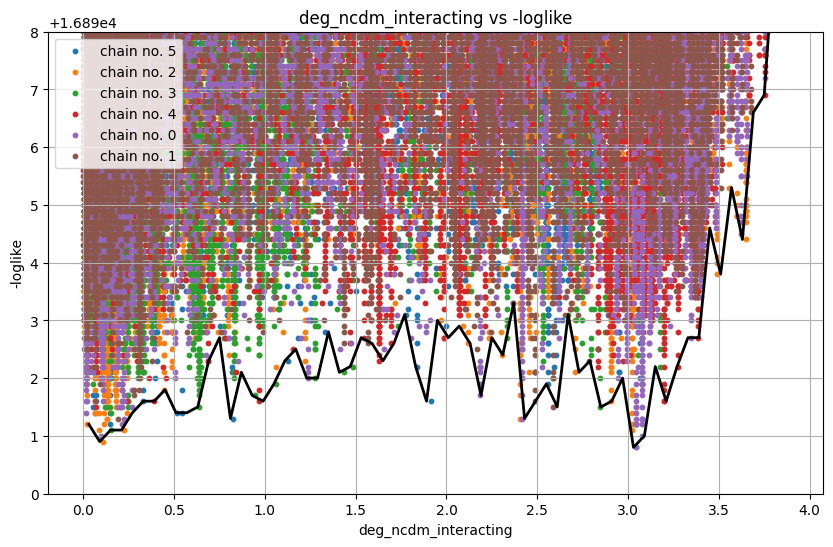

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import glob
import os

folder_path = "/home/jthybo/connect_wsl/resources/montepython_public/chains/SIDR_interacting_and_std_T_3_1mio/"
file_pattern = os.path.join(folder_path, "2026-03*.txt")
txt_files = glob.glob(file_pattern)

plt.figure(figsize=(10, 6))

# Global plotting limits
y_max_glob = 16898.0
y_min_glob = 16890.0

# Downsampling step
step = 10

# Store all data (downsampled)
all_data = []

# ----------- LOAD + DOWNSAMPLE + PLOT ----------- #
for file in txt_files:
    filename = os.path.basename(file)
    chain_number = int(filename.split("__")[-1].replace(".txt", ""))
    label = f"chain no. {chain_number}"

    # Load only needed columns: column 1 (-loglike) and 11 (deg_ncdm_interacting)
    data = np.loadtxt(file, usecols=(1, 11))  # -loglike, deg_ncdm_interacting

    # Downsample immediately
    data = data[::step]

    # Store for combined dataset
    all_data.append(data)

    x_chain = data[:, 1]  # deg_ncdm_interacting
    y_chain = data[:, 0]  # -loglike
    print(y_chain.min(), y_chain.max())

    plt.scatter(x_chain, y_chain, s=10, marker='o', label=label)

# ----------- COMBINE DATA ----------- #
combined_dataset = np.vstack(all_data)

x = combined_dataset[:, 1]  # deg_ncdm_interacting
y = combined_dataset[:, 0]  # -loglike

# ----------- SORT FOR BINNING ----------- #
sort_idx = np.argsort(x)
x_sorted = x[sort_idx]
y_sorted = y[sort_idx]

# ----------- BINNING FOR TREND LINE ----------- #
bins_width = 0.06
bins = np.arange(x.min(), x.max() + bins_width, bins_width)

trend_x = []
trend_y = []

for i in range(len(bins) - 1):
    mask = (x_sorted >= bins[i]) & (x_sorted < bins[i + 1])
    y_in_bin = y_sorted[mask]

    if len(y_in_bin) > 0:
        trend_y.append(y_in_bin.min())
        trend_x.append((bins[i] + bins[i + 1]) / 2)

trend_x = np.array(trend_x)
trend_y = np.array(trend_y)

# ----------- TREND LINE ----------- #
plt.plot(trend_x, trend_y, color='black', linestyle='-', linewidth=2)

# ----------- FINAL PLOT SETTINGS ----------- #
plt.title('deg_ncdm_interacting vs -loglike')
plt.xlabel('deg_ncdm_interacting')
plt.ylabel('-loglike')

print('Global min value of -loglike:', y_min_glob)
print('Global max value of -loglike:', y_max_glob)

plt.yticks(np.linspace(y_min_glob, y_max_glob, 9))
plt.ylim(y_min_glob, y_max_glob)

plt.legend(loc='upper left')
plt.grid()

plt.show()